In [3]:
import pandas as pd

credit = pd.read_csv('data/credit_final.csv')
credit = credit.rename(columns={'age_groups_60+': 'age_groups_60_plus',
                                'age_groups_=<30': 'age_groups_less_equal_30'})

# Podział zbioru

In [5]:
from sklearn.model_selection import train_test_split

X = credit.drop(columns=['risk'])
y = credit['risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
y.value_counts(normalize=True)

risk
1    0.7
0    0.3
Name: proportion, dtype: float64

# Drzewo decyzyjne

In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf_tree = DecisionTreeClassifier(random_state=42, max_depth=3)
clf_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

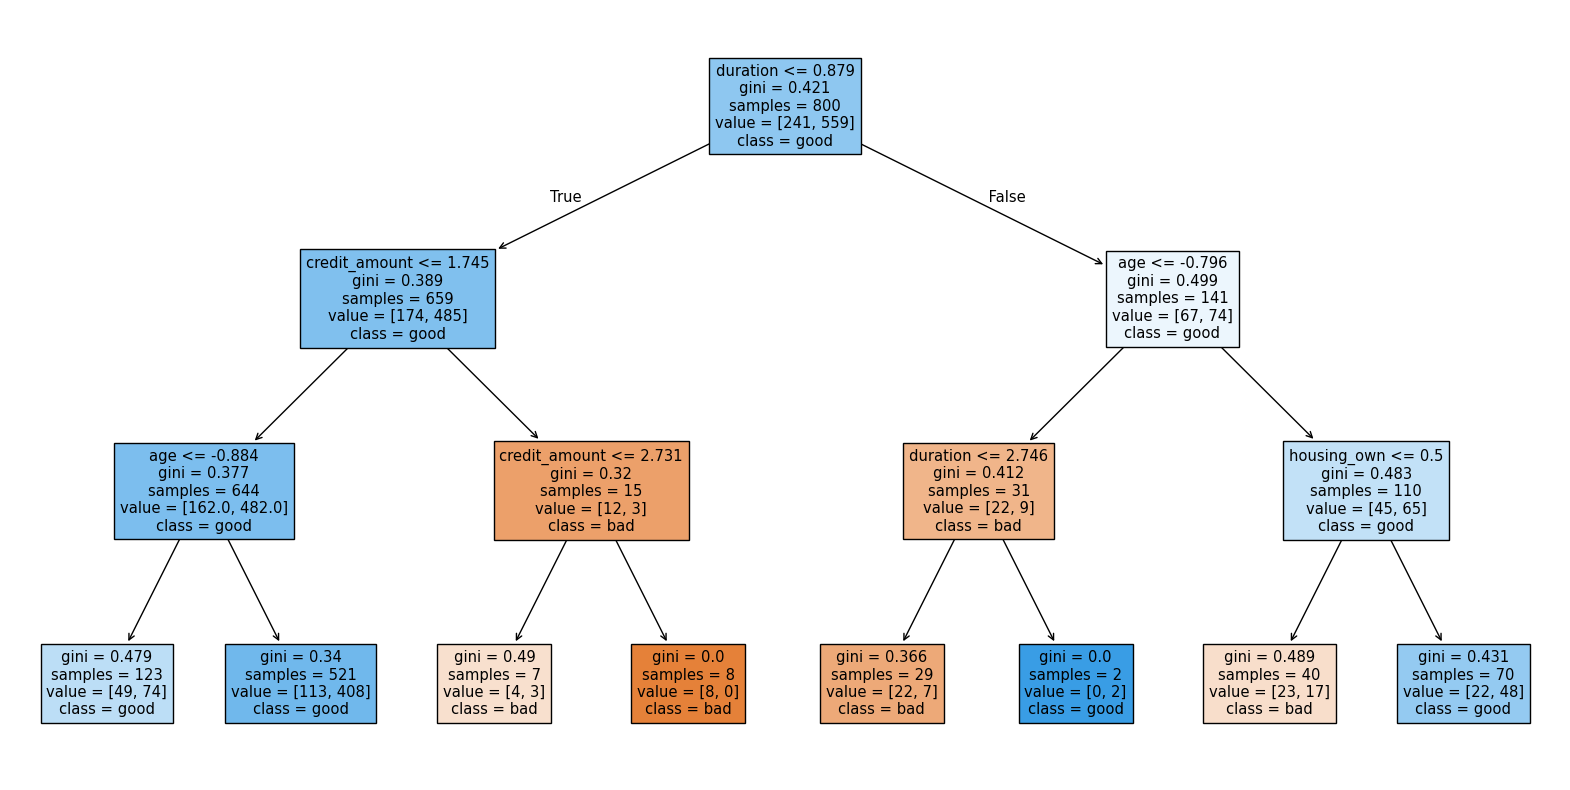

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(clf_tree, filled=True, feature_names=X.columns, class_names=['bad', 'good'])
plt.show()

## Ocena jakości modelu

In [25]:
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, balanced_accuracy_score)

y_pred_train_tree = clf_tree.predict(X_train)
confusion_matrix(y_train, y_pred_train_tree)

array([[ 57, 184],
       [ 27, 532]])

In [27]:
print(classification_report(y_train, y_pred_train_tree))

              precision    recall  f1-score   support

           0       0.68      0.24      0.35       241
           1       0.74      0.95      0.83       559

    accuracy                           0.74       800
   macro avg       0.71      0.59      0.59       800
weighted avg       0.72      0.74      0.69       800



In [ ]:
def evaluate_model(y_true, y_pred):

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    specificity = tn / (tn + fp)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    

In [29]:
evaluate_model(y_train, y_pred_train_tree)

Confusion Matrix:
[[ 57 184]
 [ 27 532]]
Accuracy: 0.7362
Balanced Accuracy: 0.5941
Precision: 0.7430
Recall: 0.9517
F1 Score: 0.8345
Specificity: 0.2365


In [30]:
y_pred_test_tree = clf_tree.predict(X_test)
evaluate_model(y_test, y_pred_test_tree)

Confusion Matrix:
[[ 11  48]
 [  8 133]]
Accuracy: 0.7200
Balanced Accuracy: 0.5649
Precision: 0.7348
Recall: 0.9433
F1 Score: 0.8261
Specificity: 0.1864


Accuracy = 0,72 = 72% dokładności modelu

Balanced accuracy = 0,56 = 56% trafności modelu z uwzględnieniem nierównowagi klas

Precision (precyzja) = 0,73 = 73% klientów zaklasyfikowanych jako dobrzy klienci to rzeczywiście dobrzy klienci

Recall (czułość) = 0,94 = udaje się zaklasyfikować 94% dobrych klientów, a tylko 6% klasyfikuje jako złych

Specificity (swoistość) = 0,18 = tylko 18% złych klientów zostało poprawnie rozpoznanych, a 82% złych klientów jest klasyfikowanych jako dobrzy klienci

F1-score = 0,82 = 82% skutczności modelu dla klasy dobrzy klienci

# Krzywa ROC

AUC: 0.5448


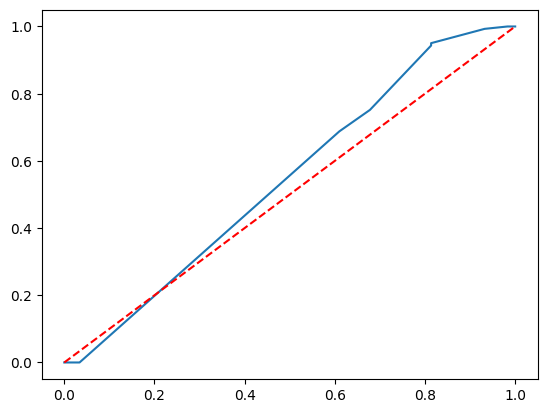

In [34]:
from sklearn.metrics import roc_auc_score, roc_curve

y_pred_proba_test_tree = clf_tree.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test_tree)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_test_tree):.4f}")

# Maszyna wektorów nośnych (SVM)

In [49]:
from sklearn.svm import SVC

# clf_svm = SVC(random_state=42, probability=True, kernel='linear')
# clf_svm = SVC(random_state=42, probability=True, kernel='poly')
clf_svm = SVC(random_state=42, probability=True, kernel='rbf')
# clf_svm = SVC(random_state=42, probability=True, kernel='sigmoid')
clf_svm.fit(X_train, y_train)

y_pred_train_svm = clf_svm.predict(X_train)
y_pred_test_svm = clf_svm.predict(X_test)

In [50]:
evaluate_model(y_train, y_pred_train_svm)

Confusion Matrix:
[[ 70 171]
 [ 10 549]]
Accuracy: 0.7738
Balanced Accuracy: 0.6363
Precision: 0.7625
Recall: 0.9821
F1 Score: 0.8585
Specificity: 0.2905


In [51]:
evaluate_model(y_test, y_pred_test_svm)

Confusion Matrix:
[[  7  52]
 [  9 132]]
Accuracy: 0.6950
Balanced Accuracy: 0.5274
Precision: 0.7174
Recall: 0.9362
F1 Score: 0.8123
Specificity: 0.1186


AUC: 0.6751


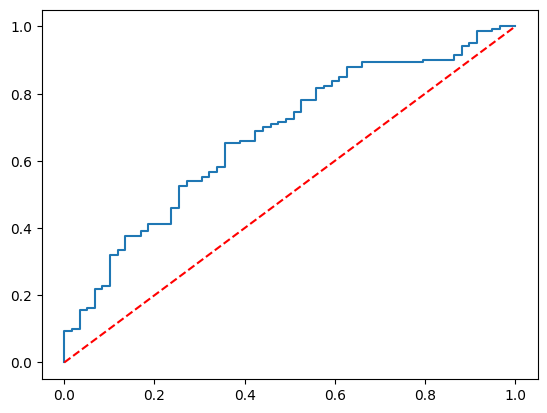

In [52]:
def roc_plot(y_true, X, model):
    y_pred_proba = model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--', color='red')
    print(f"AUC: {roc_auc_score(y_true, y_pred_proba):.4f}")

roc_plot(y_test, X_test, clf_svm)

# Las losowy

In [59]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=7)
clf_rf.fit(X_train, y_train)

y_pred_train_rf = clf_rf.predict(X_train)
y_pred_test_rf = clf_rf.predict(X_test)

In [60]:
evaluate_model(y_train, y_pred_train_rf)

Confusion Matrix:
[[101 140]
 [  0 559]]
Accuracy: 0.8250
Balanced Accuracy: 0.7095
Precision: 0.7997
Recall: 1.0000
F1 Score: 0.8887
Specificity: 0.4191


In [61]:
evaluate_model(y_test, y_pred_test_rf)

Confusion Matrix:
[[ 10  49]
 [  7 134]]
Accuracy: 0.7200
Balanced Accuracy: 0.5599
Precision: 0.7322
Recall: 0.9504
F1 Score: 0.8272
Specificity: 0.1695


AUC: 0.6556


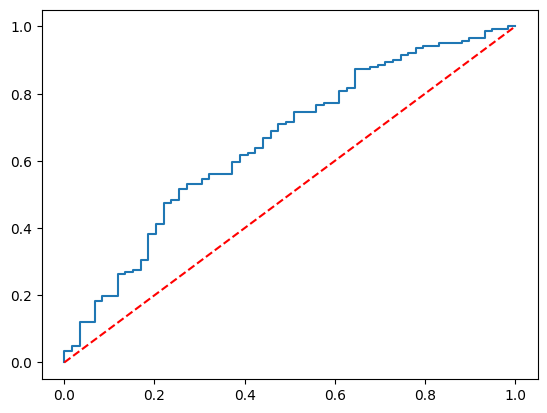

In [62]:
roc_plot(y_test, X_test, clf_rf)

# Boosting gradientowy

In [68]:
from sklearn.ensemble import GradientBoostingClassifier

clf_gb = GradientBoostingClassifier(random_state=42, n_estimators=40, max_depth=7)
clf_gb.fit(X_train, y_train)

y_pred_train_gb = clf_gb.predict(X_train)
y_pred_test_gb = clf_gb.predict(X_test)

In [69]:
evaluate_model(y_train, y_pred_train_gb)

Confusion Matrix:
[[228  13]
 [  0 559]]
Accuracy: 0.9838
Balanced Accuracy: 0.9730
Precision: 0.9773
Recall: 1.0000
F1 Score: 0.9885
Specificity: 0.9461


In [70]:
evaluate_model(y_test, y_pred_test_gb)

Confusion Matrix:
[[ 15  44]
 [ 15 126]]
Accuracy: 0.7050
Balanced Accuracy: 0.5739
Precision: 0.7412
Recall: 0.8936
F1 Score: 0.8103
Specificity: 0.2542


AUC: 0.6833


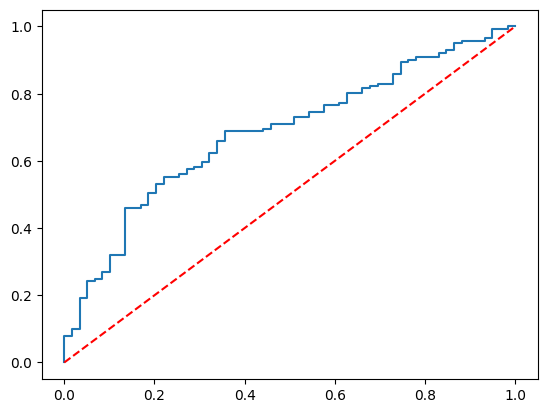

In [71]:
roc_plot(y_test, X_test, clf_gb)

In [72]:
! pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
from xgboost import XGBClassifier

clf_xgb = XGBClassifier(random_state=42, n_estimators=40, max_depth=7)
clf_xgb.fit(X_train, y_train)

y_pred_train_xgb = clf_xgb.predict(X_train)
y_pred_test_xgb = clf_xgb.predict(X_test)

In [74]:
evaluate_model(y_train, y_pred_train_xgb)

Confusion Matrix:
[[233   8]
 [  0 559]]
Accuracy: 0.9900
Balanced Accuracy: 0.9834
Precision: 0.9859
Recall: 1.0000
F1 Score: 0.9929
Specificity: 0.9668


In [75]:
evaluate_model(y_test, y_pred_test_xgb)

Confusion Matrix:
[[ 16  43]
 [ 21 120]]
Accuracy: 0.6800
Balanced Accuracy: 0.5611
Precision: 0.7362
Recall: 0.8511
F1 Score: 0.7895
Specificity: 0.2712


AUC: 0.6676


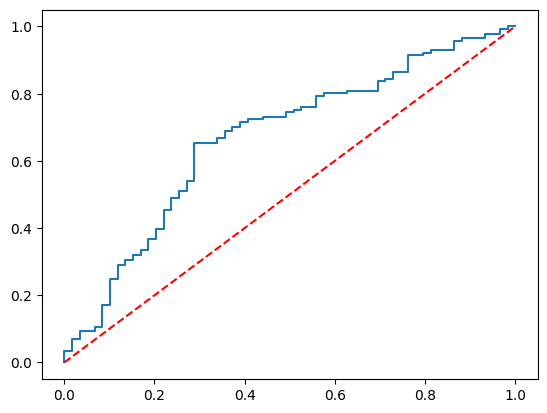

In [76]:
roc_plot(y_test, X_test, clf_xgb)

# Walidacja krzyżowa

In [78]:
from sklearn.model_selection import cross_val_score

scores_cv = cross_val_score(clf_xgb, X_train, y_train, cv=5, scoring='roc_auc')
scores_cv

array([0.64938408, 0.61160714, 0.67150298, 0.6577381 , 0.68024554])

In [79]:
print(scores_cv.mean())

0.6540955655911013
